In [14]:
import numpy as np
import matplotlib.pyplot as plt 

In [15]:
import os
plot_dir = os.path.join("..", "plots", "eda")
os.makedirs(plot_dir, exist_ok=True)

In [16]:
np.random.seed(42)

T = 500
print(f"T:{T}\n")

rho = np.array([0.2, 0.8])
sigma = np.array([0.5, 1.0])
print(f"rho: {rho}\n sigma:{sigma}\n")

P = np.array(
    [[0.95, 0.05],
    [0.05, 0.95]]
    )
print(f"P: {P}\n")

states = np.zeros(T, dtype=int)
y = np.zeros(T)
# print(f"states: {states}\n y: {y}\n")

states[0] = np.random.choice([0,1])
y[0] = np.random.normal()
print(f"states[0]: {states[0]}\n y[0]: {y[0]}\n")

for t in range(1, T):
    states[t] = np.random.choice([0,1], p=P[states[t-1]])
    s = states[t]
    y[t] = rho[s]*y[t-1] + np.random.normal(scale=sigma[s])

    if t % 50 == 0:
        col1 = f"iteration {t}"
        col2 = f"state: {s}"
        col3 = f"y[{t}]: {y[t]:.4f}"
        print(f"{col1:<20s}{col2:<15s}{col3}")


T:500

rho: [0.2 0.8]
 sigma:[0.5 1. ]

P: [[0.95 0.05]
 [0.05 0.95]]

states[0]: 0
 y[0]: -0.5502344891639495

iteration 50        state: 0       y[50]: -0.1451
iteration 100       state: 1       y[100]: 2.1131
iteration 150       state: 0       y[150]: 1.6434
iteration 200       state: 1       y[200]: 0.6728
iteration 250       state: 1       y[250]: 0.5355
iteration 300       state: 0       y[300]: 0.0844
iteration 350       state: 0       y[350]: 0.4408
iteration 400       state: 1       y[400]: 1.8351
iteration 450       state: 0       y[450]: -0.3329


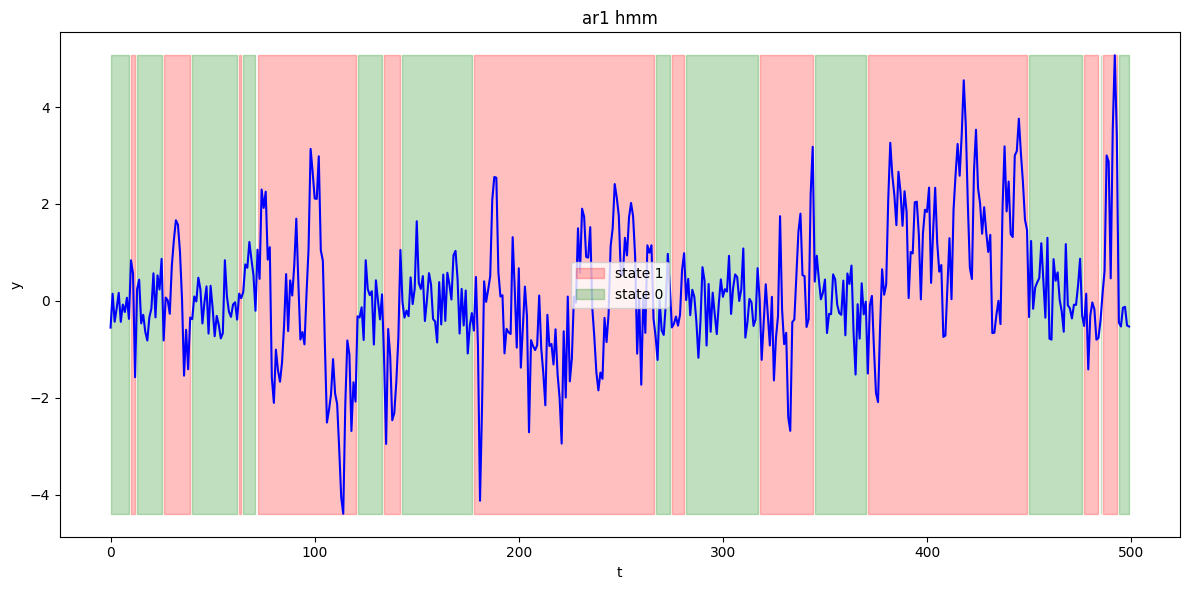

In [17]:
plt.figure(figsize=(12,6))
plt.plot(y, color="blue")
plt.fill_between(range(T), y.min(), y.max(), where=(states==1), alpha=0.25, color="red", label="state 1")
plt.fill_between(range(T), y.min(), y.max(), where=(states==0), alpha=0.25, color="green", label="state 0")
plt.title("ar1 hmm")
plt.xlabel("t")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "ar1_hmm_simulated_path.pdf"), bbox_inches="tight")
plt.show()

In [18]:
def ark(T, k, rho, sigma, P):

    assert len(rho) == k, f"Error rho length must be equal to {k} length"
    assert len(sigma) == k, f"Error sigma length must be equal to {k} length"
    assert P.shape == (k, k), f"Error P must be a {k}x{k} matrix"
    assert np.allclose(P.sum(axis=1), 1), "Error every row in transition matrix P must sum to 1.0"

    states = np.zeros(T, dtype=int)
    y = np.zeros(T)

    states[0] = np.random.choice(k)
    y[0] = np.random.normal()

    for t in range(1, T):
        states[t] = np.random.choice(k, p=P[states[t-1]])
        s = states[t]
        y[t] = rho[s] * y[t-1] + np.random.normal(scale=sigma[s])

    return states, y

In [19]:
np.random.seed(42)

T = 500
k = 4

rho_params = np.random.uniform(-0.8, 0.8, k)
sigma_params = np.random.uniform(0.5, 2.0, k)

print(f"rho_params: {rho_params}")
print(f"sigma_params: {sigma_params}")

P_matrix = np.random.dirichlet(np.ones(k), size=k)

simulated_states, simulated_y = ark(T, k, rho_params, sigma_params, P_matrix)

print(f"simulated {T} steps for {k} states")
print(f"first 5 states: {simulated_states[:5]}")
print(f"first 5 y values: {np.round(simulated_y[:5], 4)}")
print(f"\n")

rho_params: [-0.20073581  0.72114289  0.37119031  0.15785357]
sigma_params: [0.73402796 0.73399178 0.58712542 1.79926422]
simulated 500 steps for 4 states
first 5 states: [1 0 3 2 1]
first 5 y values: [ 0.2221 -0.6083  1.945   0.6604 -1.0113]




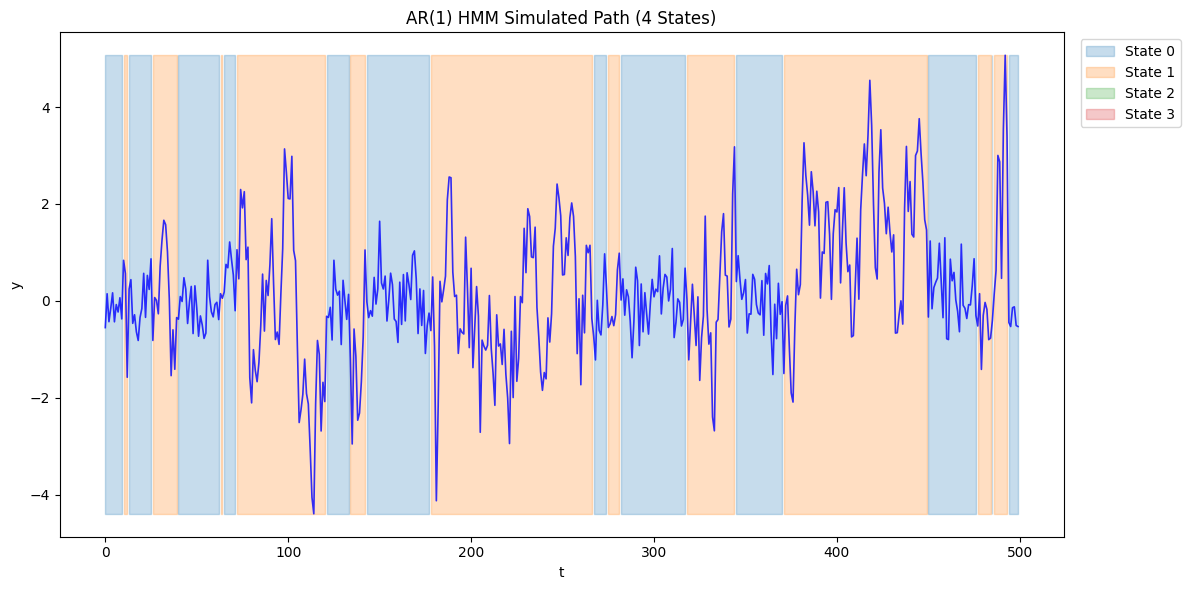

In [20]:
plt.figure(figsize=(12,6))
plt.plot(y, color="blue", linewidth=1.2, alpha=0.8)
cmap = plt.cm.get_cmap('tab10')

for i in range(k):
    plt.fill_between(
        range(T), 
        y.min(), 
        y.max(), 
        where=(states == i), 
        alpha=0.25, 
        color=cmap(i), 
        label=f"State {i}"
    )

plt.title(f"AR(1) HMM Simulated Path ({k} States)")
plt.xlabel("t")
plt.ylabel("y")

plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()

plt.savefig(os.path.join(plot_dir, f"ar1_hmm_{k}_states.pdf"), bbox_inches="tight")

plt.show()